In [1]:
# =============================================================================
# PHASE 1 — STEP 1.2c: SIMPLE SHAPES DATASET
# Mechanistic Analysis of T2I Hallucinations via Mode Interpolation
# =============================================================================
#
# PURPOSE
# ───────
# Validate that trajectory variance detects mode interpolation on a controlled
# image dataset (circles vs squares) before scaling to Stable Diffusion.
#
# DEAD ZONE DEFINITION
# ───────────────────
# Dead zone = images the classifier predicts as Ambiguous (class 2)
#             OR where max softmax confidence < DEAD_ZONE_CONF_THRESH
# Directly parallels Phase 4: classifier uncertainty here ↔ CLIP score there.
#
# KILL-SWITCH
# ───────────
# Ratio = Mean_Var(DeadZone) / Mean_Var(Mode) > 5.0
#
# KEY DESIGN DECISIONS (with justification)
# ──────────────────────────────────────────
# T = 100 steps, window = last 50 steps (i < 50 → t = 0..49):
#   The window collects x₀ estimates at timesteps t=0 to t=49.
#   At T=100: ᾱ at t=49 = 0.494 → 50% signal, meaningful uncertainty.
#   At T=500: ᾱ at t=49 = 0.972 → 97% signal, near-zero variance for everyone.
#   T=500 was tried and produced ratio=0.25 (FAIL) because the window
#   was in the wrong regime — model fully committed at ᾱ=0.97.
#
# DIFF_EPOCHS = 6000:
#   15000 epochs → loss=0.00115, 1/2000 dead zone samples → no statistical power.
#   6000 epochs → model generates clean shapes AND ~5-15% ambiguous ones.
#   Target: 50-300 dead zone samples out of 2000 for a valid ratio estimate.
#
# 3-CLASS CLASSIFIER (Circle / Square / Ambiguous):
#   Binary classifier is overconfident on blends — picks one with conf=1.0.
#   3-class classifier explicitly trained on ambiguous examples (blends,
#   blurred shapes, partial shapes, noise) → correctly flags them as class 2.
# =============================================================================


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
import math
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [ ]:
IMG_SIZE              = 32
N_STEPS               = 100   
                              
DIFF_EPOCHS           = 6000  
                               
CLF_EPOCHS            = 3000
BATCH_SIZE            = 256
LR_DIFF               = 1e-3
LR_CLF                = 1e-3
N_SAMPLES             = 2000
VARIANCE_WINDOW       = 50   
KILL_SWITCH_RATIO     = 5.0

MODE_CONF_THRESH      = 0.90  
DEAD_ZONE_CONF_THRESH = 0.60  

print(f'\nConfig:')
print(f'  T (diffusion steps):  {N_STEPS}')
print(f'  Diff epochs:          {DIFF_EPOCHS}')
print(f'  Variance window:      last {VARIANCE_WINDOW} steps  (i<{VARIANCE_WINDOW} → t=0..{VARIANCE_WINDOW-1})')
print(f'  Mode threshold:       clf confidence >= {MODE_CONF_THRESH}')
print(f'  Dead zone threshold:  clf confidence <  {DEAD_ZONE_CONF_THRESH}')
print(f'  Kill-switch:          ratio > {KILL_SWITCH_RATIO}')



Config:
  T (diffusion steps):  100
  Diff epochs:          6000
  Variance window:      last 50 steps  (i<50 → t=0..49)
  Mode threshold:       clf confidence >= 0.9
  Dead zone threshold:  clf confidence <  0.6
  Kill-switch:          ratio > 5.0



Noise schedule (cosine, T=100):
  ᾱ at t=0   (end of reverse):   0.99937  (should be ~1.0)
  ᾱ at t=50 (midpoint):          0.49384
  ᾱ at t=99 (start of reverse): 0.00000  (should be ~0.0)

  Variance window (i<50 → t=0..49):
    ᾱ at window start t=49: 0.49384  ← 49% signal
    ᾱ at window end   t=0:   0.99937
    Window ᾱ span: [0.494 → 0.999]

  ✅ Window ᾱ range [0.494→0.999] is good for variance measurement.


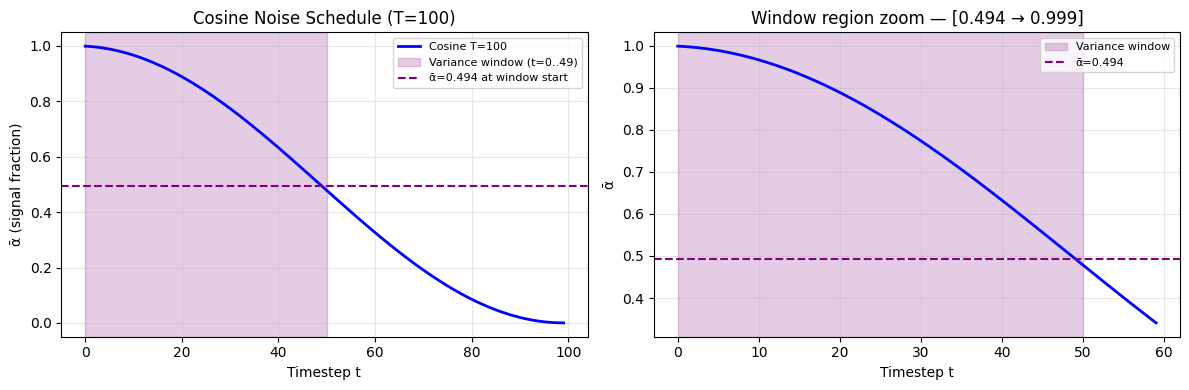

In [ ]:
def cosine_beta_schedule(T, s=0.008):
    steps = T + 1
    x     = torch.linspace(0, T, steps)
    ac    = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
    ac    = ac / ac[0]
    betas = 1 - (ac[1:] / ac[:-1])
    return torch.clamp(betas, 1e-4, 0.9999)


betas          = cosine_beta_schedule(N_STEPS).to(device)
alphas         = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

window_start_alpha = alphas_cumprod[VARIANCE_WINDOW - 1].item()
window_end_alpha   = alphas_cumprod[0].item()

print(f'\nNoise schedule (cosine, T={N_STEPS}):')
print(f'  ᾱ at t=0   (end of reverse):   {window_end_alpha:.5f}  (should be ~1.0)')
print(f'  ᾱ at t={N_STEPS//2} (midpoint):          {alphas_cumprod[N_STEPS//2-1].item():.5f}')
print(f'  ᾱ at t={N_STEPS-1} (start of reverse): {alphas_cumprod[-1].item():.5f}  (should be ~0.0)')
print(f'\n  Variance window (i<{VARIANCE_WINDOW} → t=0..{VARIANCE_WINDOW-1}):')
print(f'    ᾱ at window start t={VARIANCE_WINDOW-1}: {window_start_alpha:.5f}  ← {window_start_alpha*100:.0f}% signal')
print(f'    ᾱ at window end   t=0:   {window_end_alpha:.5f}')
print(f'    Window ᾱ span: [{window_start_alpha:.3f} → {window_end_alpha:.3f}]')

if window_start_alpha > 0.90:
    print(f'\n  ⚠️  Window start ᾱ={window_start_alpha:.3f} > 0.90 — variance will be near-zero for everyone.')
    print(f'     Reduce N_STEPS or reduce VARIANCE_WINDOW.')
elif window_start_alpha < 0.30:
    print(f'\n  ⚠️  Window start ᾱ={window_start_alpha:.3f} < 0.30 — window is too noisy.')
    print(f'     Increase N_STEPS or reduce VARIANCE_WINDOW.')
else:
    print(f'\n  ✅ Window ᾱ range [{window_start_alpha:.3f}→{window_end_alpha:.3f}] is good for variance measurement.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
t_ax = np.arange(N_STEPS)
axes[0].plot(t_ax, alphas_cumprod.cpu().numpy(), 'b-', lw=2, label=f'Cosine T={N_STEPS}')
axes[0].axvspan(0, VARIANCE_WINDOW, alpha=0.2, color='purple',
                label=f'Variance window (t=0..{VARIANCE_WINDOW-1})')
axes[0].axhline(window_start_alpha, color='purple', ls='--', lw=1.5,
                label=f'ᾱ={window_start_alpha:.3f} at window start')
axes[0].set_xlabel('Timestep t'); axes[0].set_ylabel('ᾱ (signal fraction)')
axes[0].set_title(f'Cosine Noise Schedule (T={N_STEPS})')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(t_ax[:VARIANCE_WINDOW + 10], alphas_cumprod.cpu().numpy()[:VARIANCE_WINDOW + 10],
             'b-', lw=2)
axes[1].axvspan(0, VARIANCE_WINDOW, alpha=0.2, color='purple', label='Variance window')
axes[1].axhline(window_start_alpha, color='purple', ls='--', lw=1.5,
                label=f'ᾱ={window_start_alpha:.3f}')
axes[1].set_xlabel('Timestep t'); axes[1].set_ylabel('ᾱ')
axes[1].set_title(f'Window region zoom — [{window_start_alpha:.3f} → {window_end_alpha:.3f}]')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('noise_schedule.png', dpi=150, bbox_inches='tight')
plt.show()


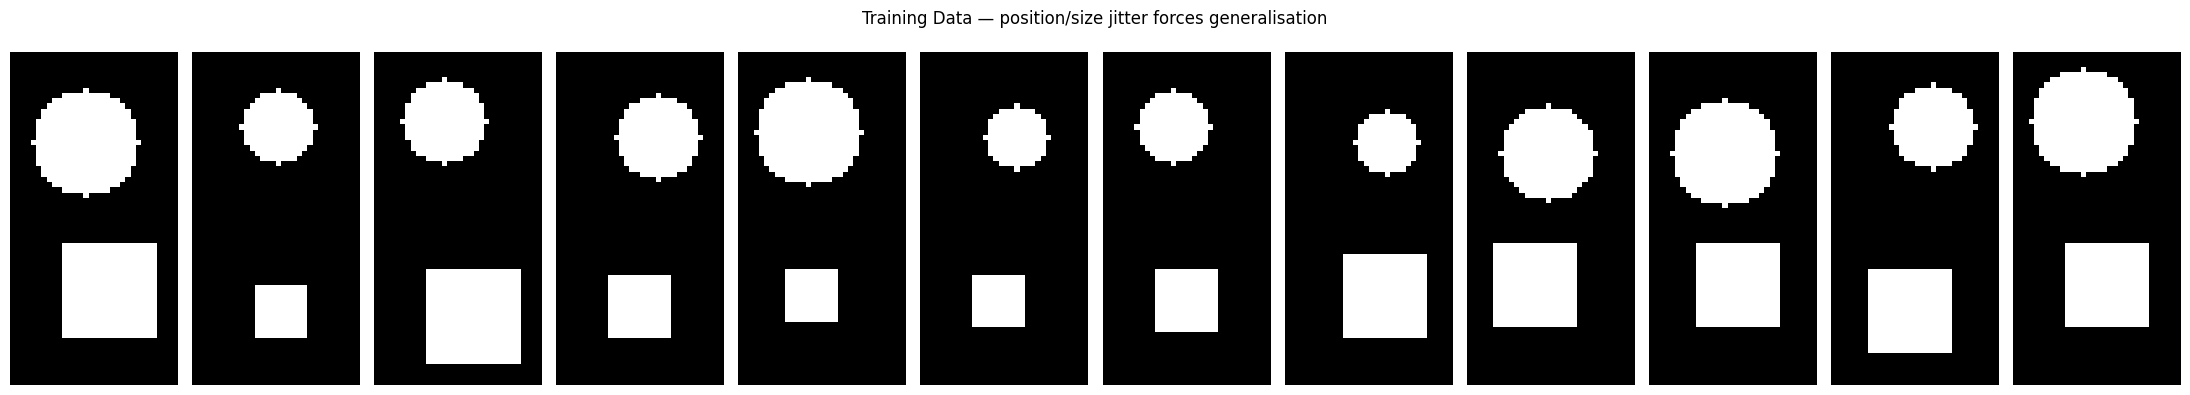

In [ ]:
def make_shape(shape_type, size=IMG_SIZE, jitter=True):
    img = np.zeros((size, size), dtype=np.float32)
    cx  = size // 2 + (np.random.randint(-3, 4) if jitter else 0)
    cy  = size // 2 + (np.random.randint(-3, 4) if jitter else 0)
    if shape_type == 0:
        r = int(size * 0.28) + (np.random.randint(-2, 3) if jitter else 0)
        Y, X = np.ogrid[:size, :size]
        img[(X - cx)**2 + (Y - cy)**2 <= r**2] = 1.0
    else:              
        half = int(size * 0.24) + (np.random.randint(-2, 3) if jitter else 0)
        img[max(0, cx-half):min(size, cx+half),
            max(0, cy-half):min(size, cy+half)] = 1.0
    return img * 2 - 1


def make_ambiguous(size=IMG_SIZE):
    """
    Five strategies chosen randomly:
      0. Alpha blend of circle + square
      1. Box-blurred shape (loses crisp edges)
      2. Partial / half-occluded shape
      3. Pure Gaussian noise
      4. Wrong-size shape (too tiny or fills canvas)
    """
    strategy = np.random.randint(0, 5)
    if strategy == 0:
        alpha = np.random.uniform(0.2, 0.8)
        img   = alpha * make_shape(0, jitter=True) + (1 - alpha) * make_shape(1, jitter=True)
    elif strategy == 1:
        base    = (make_shape(np.random.randint(0, 2), jitter=True) + 1) / 2
        k       = np.random.randint(3, 7)
        padded  = np.pad(base, k, mode='edge')
        blurred = np.zeros((size, size), dtype=np.float32)
        for dy in range(2*k + 1):
            for dx in range(2*k + 1):
                blurred += padded[dy:dy+size, dx:dx+size]
        blurred /= (2*k + 1) ** 2
        img = blurred * 2 - 1
    elif strategy == 2:
        base  = make_shape(np.random.randint(0, 2), jitter=True)
        mask  = np.zeros((size, size), dtype=np.float32)
        split = np.random.randint(size // 3, 2 * size // 3)
        if np.random.randint(0, 2) == 0:
            mask[:split, :] = 1.0
        else:
            mask[:, :split] = 1.0
        img = base * mask + (-1.0) * (1 - mask)
    elif strategy == 3:
        img = np.random.uniform(-1, 1, (size, size)).astype(np.float32)
    else:
        raw = np.zeros((size, size), dtype=np.float32)
        cx  = cy = size // 2
        if np.random.randint(0, 2) == 0:
            r = np.random.choice([2, 3, size // 2 - 1, size // 2])
            Y, X = np.ogrid[:size, :size]
            raw[(X - cx)**2 + (Y - cy)**2 <= r**2] = 1.0
        else:
            half = np.random.choice([1, 2, size // 2 - 1, size // 2])
            raw[max(0,cx-half):min(size,cx+half),
                max(0,cy-half):min(size,cy+half)] = 1.0
        img = raw * 2 - 1
    return img.astype(np.float32)


def get_diffusion_batch(bs):
    imgs = [make_shape(i % 2) for i in range(bs)]
    np.random.shuffle(imgs)
    return torch.tensor(np.stack(imgs)[:, None, :, :])


def get_classifier_batch(bs):
    imgs, labels = [], []
    for _ in range(bs):
        r = np.random.random()
        if r < 0.4:
            imgs.append(make_shape(0));    labels.append(0)
        elif r < 0.8:
            imgs.append(make_shape(1));    labels.append(1)
        else:
            imgs.append(make_ambiguous()); labels.append(2)
    return (torch.tensor(np.stack(imgs)[:, None, :, :]),
            torch.tensor(labels, dtype=torch.long))

fig, axes = plt.subplots(2, 12, figsize=(22, 4))
for i in range(12):
    axes[0, i].imshow(make_shape(0), cmap='gray', vmin=-1, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(make_shape(1), cmap='gray', vmin=-1, vmax=1)
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Circles\n(Mode A)', rotation=0, labelpad=55, va='center', fontsize=10)
axes[1, 0].set_ylabel('Squares\n(Mode B)', rotation=0, labelpad=55, va='center', fontsize=10)
plt.suptitle('Training Data — position/size jitter forces generalisation', fontsize=12)
plt.tight_layout()
plt.savefig('shapes_data.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
CLASS_NAMES = ['Circle', 'Square', 'Ambiguous']
CMAP        = {'Mode_Circle': '#27ae60', 'Mode_Square': '#2980b9',
               'DeadZone':    '#e74c3c', 'Transition':  '#f39c12'}


class ShapeClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.net(x)

    def confidence(self, x):
        with torch.no_grad():
            probs = F.softmax(self.forward(x), dim=1)
        return probs.max(dim=1).values, probs.argmax(dim=1)


class SinPE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(-math.log(10000) *
                          torch.arange(half, device=t.device) / (half - 1))
        args  = t[:, None].float() * freqs[None]
        return torch.cat([args.sin(), args.cos()], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, ch, td):
        super().__init__()
        self.n1 = nn.GroupNorm(8, ch); self.c1 = nn.Conv2d(ch, ch, 3, padding=1)
        self.n2 = nn.GroupNorm(8, ch); self.c2 = nn.Conv2d(ch, ch, 3, padding=1)
        self.tp = nn.Linear(td, ch);   self.act = nn.SiLU()

    def forward(self, x, t):
        h = self.c1(self.act(self.n1(x)))
        h = h + self.tp(self.act(t))[:, :, None, None]
        h = self.c2(self.act(self.n2(h)))
        return x + h


class DiffusionUNet(nn.Module):
    def __init__(self, in_ch=1, base_ch=32, td=128):
        super().__init__()
        ch = base_ch
        self.time_mlp = nn.Sequential(
            SinPE(td), nn.Linear(td, td*2), nn.SiLU(), nn.Linear(td*2, td))
        self.enc_in = nn.Conv2d(in_ch, ch,   3, padding=1)
        self.enc1   = ResBlock(ch,   td)
        self.down1  = nn.Conv2d(ch,   ch*2, 4, stride=2, padding=1)
        self.enc2   = ResBlock(ch*2, td)
        self.down2  = nn.Conv2d(ch*2, ch*4, 4, stride=2, padding=1)
        self.mid1   = ResBlock(ch*4, td)
        self.mid2   = ResBlock(ch*4, td)
        self.up1    = nn.ConvTranspose2d(ch*4, ch*2, 4, stride=2, padding=1)
        self.p1     = nn.Conv2d(ch*4, ch*2, 1)
        self.dec1   = ResBlock(ch*2, td)
        self.up2    = nn.ConvTranspose2d(ch*2, ch,   4, stride=2, padding=1)
        self.p2     = nn.Conv2d(ch*2, ch,   1)
        self.dec2   = ResBlock(ch,   td)
        self.out    = nn.Sequential(nn.GroupNorm(8, ch), nn.SiLU(),
                                    nn.Conv2d(ch, in_ch, 1))

    def forward(self, x, t):
        te = self.time_mlp(t)
        s1 = self.enc1(self.enc_in(x), te)
        s2 = self.enc2(self.down1(s1), te)
        h  = self.mid2(self.mid1(self.down2(s2), te), te)
        h  = self.dec1(self.p1(torch.cat([self.up1(h), s2], 1)), te)
        h  = self.dec2(self.p2(torch.cat([self.up2(h), s1], 1)), te)
        return self.out(h)


clf  = ShapeClassifier().to(device)
unet = DiffusionUNet(base_ch=32).to(device)

print(f'\nClassifier params:     {sum(p.numel() for p in clf.parameters()):,}')
print(f'Diffusion UNet params: {sum(p.numel() for p in unet.parameters()):,}')

with torch.no_grad():
    _x = torch.randn(4, 1, IMG_SIZE, IMG_SIZE).to(device)
    _t = torch.randint(0, N_STEPS, (4,)).to(device)
    assert clf(_x).shape == (4, 3),                       
    assert unet(_x, _t).shape == (4, 1, IMG_SIZE, IMG_SIZE), 
print('Model forward pass: ✅')


Classifier params:     25,699
Diffusion UNet params: 1,239,265
Model forward pass: ✅



Training classifier for 3000 epochs...


Classifier: 100%|██████████| 3000/3000 [00:42<00:00, 70.97it/s]


  Circle accuracy: 100.0%
  Square accuracy: 100.0%
  Ambiguous accuracy: 98.6%
Overall classifier accuracy: 99.7%
✅ Classifier accuracy gate passed


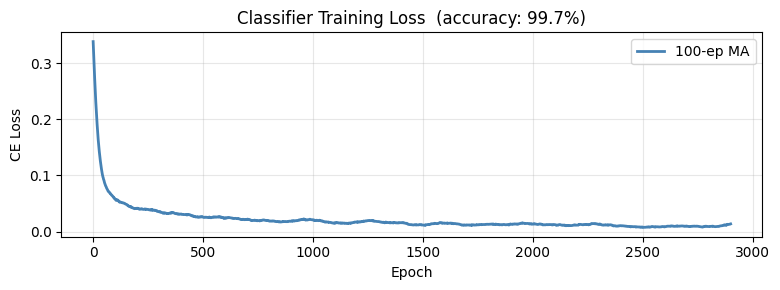

In [ ]:
clf_opt    = optim.Adam(clf.parameters(), lr=LR_CLF)
clf_losses = []

print(f'\nTraining classifier for {CLF_EPOCHS} epochs...')
clf.train()
for ep in tqdm(range(CLF_EPOCHS), desc='Classifier'):
    imgs, lbls = get_classifier_batch(BATCH_SIZE)
    imgs, lbls = imgs.to(device), lbls.to(device)
    loss = F.cross_entropy(clf(imgs), lbls)
    clf_opt.zero_grad(); loss.backward(); clf_opt.step()
    clf_losses.append(loss.item())

clf.eval()
with torch.no_grad():
    t_imgs, t_lbls = get_classifier_batch(3000)
    preds_all      = clf(t_imgs.to(device)).argmax(dim=1).cpu()
    clf_acc        = (preds_all == t_lbls).float().mean().item()
    for cls, name in [(0, 'Circle'), (1, 'Square'), (2, 'Ambiguous')]:
        mask    = t_lbls == cls
        cls_acc = (preds_all[mask] == t_lbls[mask]).float().mean().item()
        print(f'  {name} accuracy: {cls_acc*100:.1f}%')

print(f'Overall classifier accuracy: {clf_acc*100:.1f}%')
assert clf_acc >= 0.90, (
    f'Classifier accuracy {clf_acc*100:.1f}% < 90%. Increase CLF_EPOCHS.')
print('✅ Classifier accuracy gate passed')

plt.figure(figsize=(8, 3))
w  = 100
ma = np.convolve(clf_losses, np.ones(w)/w, mode='valid')
plt.plot(ma, color='steelblue', lw=2, label=f'{w}-ep MA')
plt.xlabel('Epoch'); plt.ylabel('CE Loss')
plt.title(f'Classifier Training Loss  (accuracy: {clf_acc*100:.1f}%)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('classifier_loss.png', dpi=150, bbox_inches='tight')
plt.show()


Classifier sanity check:
Image                      Conf   Raw class  Region             Expected
---------------------------------------------------------------------------
Pure Circle              0.9999      Circle  Mode_Circle        Mode  ✅
Pure Square              1.0000      Square  Mode_Square        Mode  ✅
50/50 Blend              0.9993   Ambiguous  DeadZone           DeadZone  ✅
70/30 Blend              0.9991   Ambiguous  DeadZone           DeadZone  ✅
30/70 Blend              0.7179   Ambiguous  DeadZone           DeadZone  ✅
Pure Noise               1.0000   Ambiguous  DeadZone           DeadZone  ✅
make_ambiguous           1.0000   Ambiguous  DeadZone           DeadZone  ✅

✅ 50/50 blend → DeadZone (raw=Ambiguous)
✅ Pure noise → DeadZone (raw=Ambiguous)

✅ All sanity check assertions passed


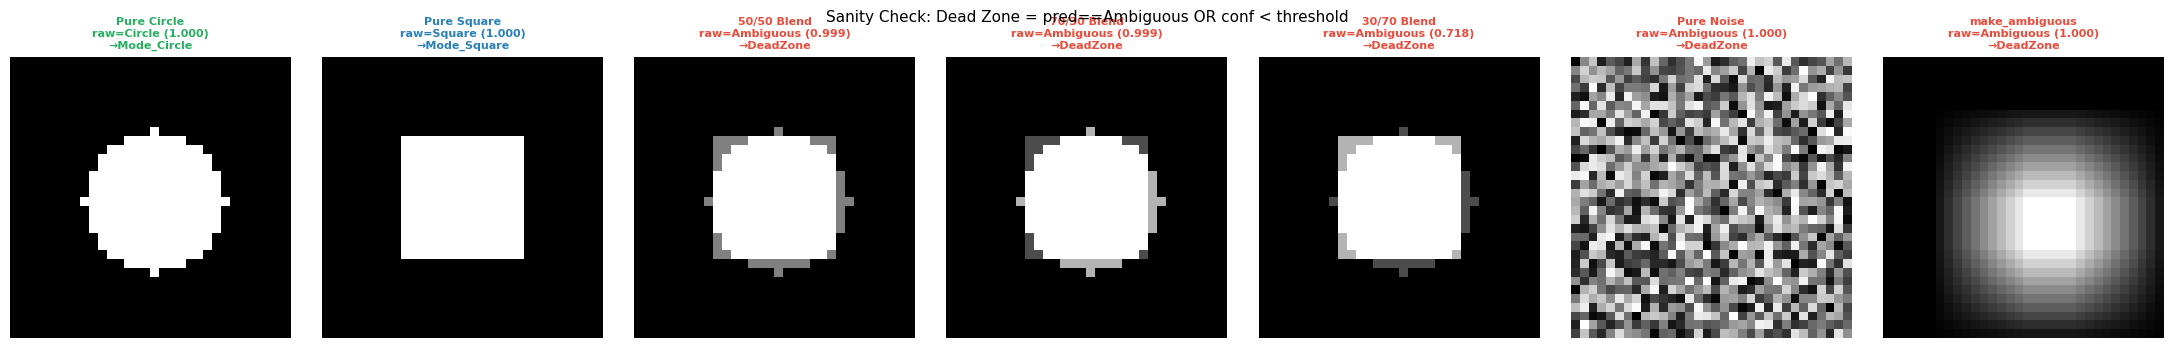

In [ ]:
def classify_image(img_2d_np):
    clf.eval()
    t = torch.tensor(img_2d_np[None, None, :, :], dtype=torch.float32).to(device)
    with torch.no_grad():
        probs = F.softmax(clf(t), dim=1)
    conf = probs.max(dim=1).values.item()
    pred = probs.argmax(dim=1).item()

    is_dead = (pred == 2) or (conf < DEAD_ZONE_CONF_THRESH)

    if is_dead:
        region = 'DeadZone'
    elif conf >= MODE_CONF_THRESH:
        region = 'Mode_Circle' if pred == 0 else 'Mode_Square'
    else:
        region = 'Transition'

    return region, conf, pred


clean_circle = make_shape(0, jitter=False)
clean_square = make_shape(1, jitter=False)
blend_50_50  = (0.5 * clean_circle + 0.5 * clean_square).astype(np.float32)
blend_70_30  = (0.7 * clean_circle + 0.3 * clean_square).astype(np.float32)
blend_30_70  = (0.3 * clean_circle + 0.7 * clean_square).astype(np.float32)
pure_noise   = np.random.uniform(-1, 1, (IMG_SIZE, IMG_SIZE)).astype(np.float32)
partial_shp  = make_ambiguous()

test_cases = [
    ('Pure Circle',    clean_circle, 'Mode'),
    ('Pure Square',    clean_square, 'Mode'),
    ('50/50 Blend',    blend_50_50,  'DeadZone'),
    ('70/30 Blend',    blend_70_30,  'DeadZone'),
    ('30/70 Blend',    blend_30_70,  'DeadZone'),
    ('Pure Noise',     pure_noise,   'DeadZone'),
    ('make_ambiguous', partial_shp,  'DeadZone'),
]

print('\nClassifier sanity check:')
print(f'{"Image":<22} {"Conf":>8}  {"Raw class":>10}  {"Region":<18} Expected')
print('-' * 75)
synth_results = []
for name, img, expected in test_cases:
    region, conf, pred = classify_image(img)
    class_name         = CLASS_NAMES[int(pred)]
    ok = '✅' if expected.split()[0] in region else '⚠️ '
    print(f'{name:<22} {conf:>8.4f}  {class_name:>10}  {region:<18} {expected}  {ok}')
    synth_results.append((name, img, region, conf, pred))

r_circle, c_circle, p_circle = classify_image(clean_circle)
r_square, c_square, p_square = classify_image(clean_square)
r_blend,  c_blend,  p_blend  = classify_image(blend_50_50)
r_noise,  c_noise,  p_noise  = classify_image(pure_noise)

assert 'Mode' in r_circle, \
    f'Pure circle → {r_circle} (class={CLASS_NAMES[p_circle]}, conf={c_circle:.3f}). Retrain.'
assert 'Mode' in r_square, \
    f'Pure square → {r_square} (class={CLASS_NAMES[p_square]}, conf={c_square:.3f}). Retrain.'

blend_is_dead = (p_blend == 2) or (c_blend < DEAD_ZONE_CONF_THRESH)
noise_is_dead = (p_noise == 2) or (c_noise < DEAD_ZONE_CONF_THRESH)

print(f'\n✅ 50/50 blend → DeadZone (raw={CLASS_NAMES[p_blend]})' if blend_is_dead
      else f'\n⚠️  50/50 blend NOT dead zone (raw={CLASS_NAMES[p_blend]}, conf={c_blend:.3f}). '
           f'Increase CLF_EPOCHS by 1000.')
print(f'✅ Pure noise → DeadZone (raw={CLASS_NAMES[p_noise]})' if noise_is_dead
      else f'⚠️  Pure noise NOT dead zone. Increase CLF_EPOCHS.')

assert blend_is_dead, 'Blend sanity check failed — see above'
assert noise_is_dead, 'Noise sanity check failed — see above'
print('\n✅ All sanity check assertions passed')

fig, axes = plt.subplots(1, 7, figsize=(22, 3.5))
for ax, (name, img, region, conf, pred) in zip(axes, synth_results):
    ax.imshow(img, cmap='gray', vmin=-1, vmax=1)
    col = CMAP.get(region, 'gray')
    ax.set_title(f'{name}\nraw={CLASS_NAMES[int(pred)]} ({conf:.3f})\n→{region}',
                 fontsize=8, color=col, fontweight='bold')
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_edgecolor(col); sp.set_linewidth(3)
plt.suptitle('Sanity Check: Dead Zone = pred==Ambiguous OR conf < threshold', fontsize=11)
plt.tight_layout()
plt.savefig('classifier_sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()


Training diffusion model for 6000 epochs...
Snapshots at epochs: [1800, 3600, 5100, 6000]


Diffusion:  30%|███       | 1801/6000 [02:42<09:49,  7.12it/s]

  Epoch  1800 | Loss: 0.00348


Diffusion:  60%|██████    | 3601/6000 [05:23<05:32,  7.21it/s]

  Epoch  3600 | Loss: 0.00209


Diffusion:  85%|████████▌ | 5101/6000 [07:37<02:05,  7.19it/s]

  Epoch  5100 | Loss: 0.00159


Diffusion: 100%|██████████| 6000/6000 [08:59<00:00, 11.13it/s]

  Epoch  6000 | Loss: 0.00150
Diffusion training complete!


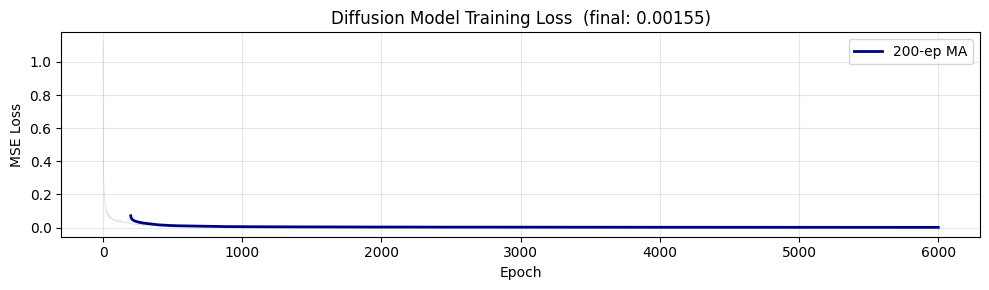

In [ ]:
diff_opt    = optim.AdamW(unet.parameters(), lr=LR_DIFF, weight_decay=1e-4)
diff_sched  = optim.lr_scheduler.CosineAnnealingLR(diff_opt, T_max=DIFF_EPOCHS, eta_min=1e-5)
diff_losses = []
snapshots   = {}
snap_at     = {int(DIFF_EPOCHS * f) for f in [0.3, 0.6, 0.85, 1.0]}

print(f'\nTraining diffusion model for {DIFF_EPOCHS} epochs...')
print(f'Snapshots at epochs: {sorted(snap_at)}')

for ep in tqdm(range(DIFF_EPOCHS), desc='Diffusion'):
    unet.train()
    x0    = get_diffusion_batch(BATCH_SIZE).to(device)
    t     = torch.randint(0, N_STEPS, (BATCH_SIZE,)).to(device)
    noise = torch.randn_like(x0)
    ab    = alphas_cumprod[t].view(-1, 1, 1, 1)
    xt    = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
    loss  = F.mse_loss(unet(xt, t), noise)
    diff_opt.zero_grad(); loss.backward()
    nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
    diff_opt.step(); diff_sched.step()
    diff_losses.append(loss.item())

    if (ep + 1) in snap_at:
        unet.eval()
        with torch.no_grad():
            xT = torch.randn(8, 1, IMG_SIZE, IMG_SIZE).to(device)
            for i in reversed(range(N_STEPS)):
                tb  = torch.full((8,), i, dtype=torch.long).to(device)
                np_ = unet(xT, tb)
                ab_ = alphas_cumprod[tb].view(-1, 1, 1, 1)
                x0p = (xT - torch.sqrt(1 - ab_) * np_) / torch.sqrt(ab_)
                x0p = x0p.clamp(-1, 1)
                if i > 0:
                    b_  = betas[tb].view(-1, 1, 1, 1)
                    al_ = alphas[tb].view(-1, 1, 1, 1)
                    xT  = ((xT - (b_ / torch.sqrt(1 - ab_)) * np_) / torch.sqrt(al_)
                           + torch.sqrt(b_) * torch.randn_like(xT))
                else:
                    xT = x0p
        snapshots[ep + 1] = xT.cpu().numpy()
        print(f'  Epoch {ep+1:5d} | Loss: {np.mean(diff_losses[-200:]):.5f}')

print('Diffusion training complete!')

plt.figure(figsize=(10, 3))
plt.plot(diff_losses, alpha=0.2, color='steelblue', lw=0.5)
w  = 200
ma = np.convolve(diff_losses, np.ones(w)/w, mode='valid')
plt.plot(range(w-1, len(diff_losses)), ma, color='navy', lw=2, label=f'{w}-ep MA')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title(f'Diffusion Model Training Loss  (final: {diff_losses[-1]:.5f})')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('diffusion_loss.png', dpi=150, bbox_inches='tight')
plt.show()


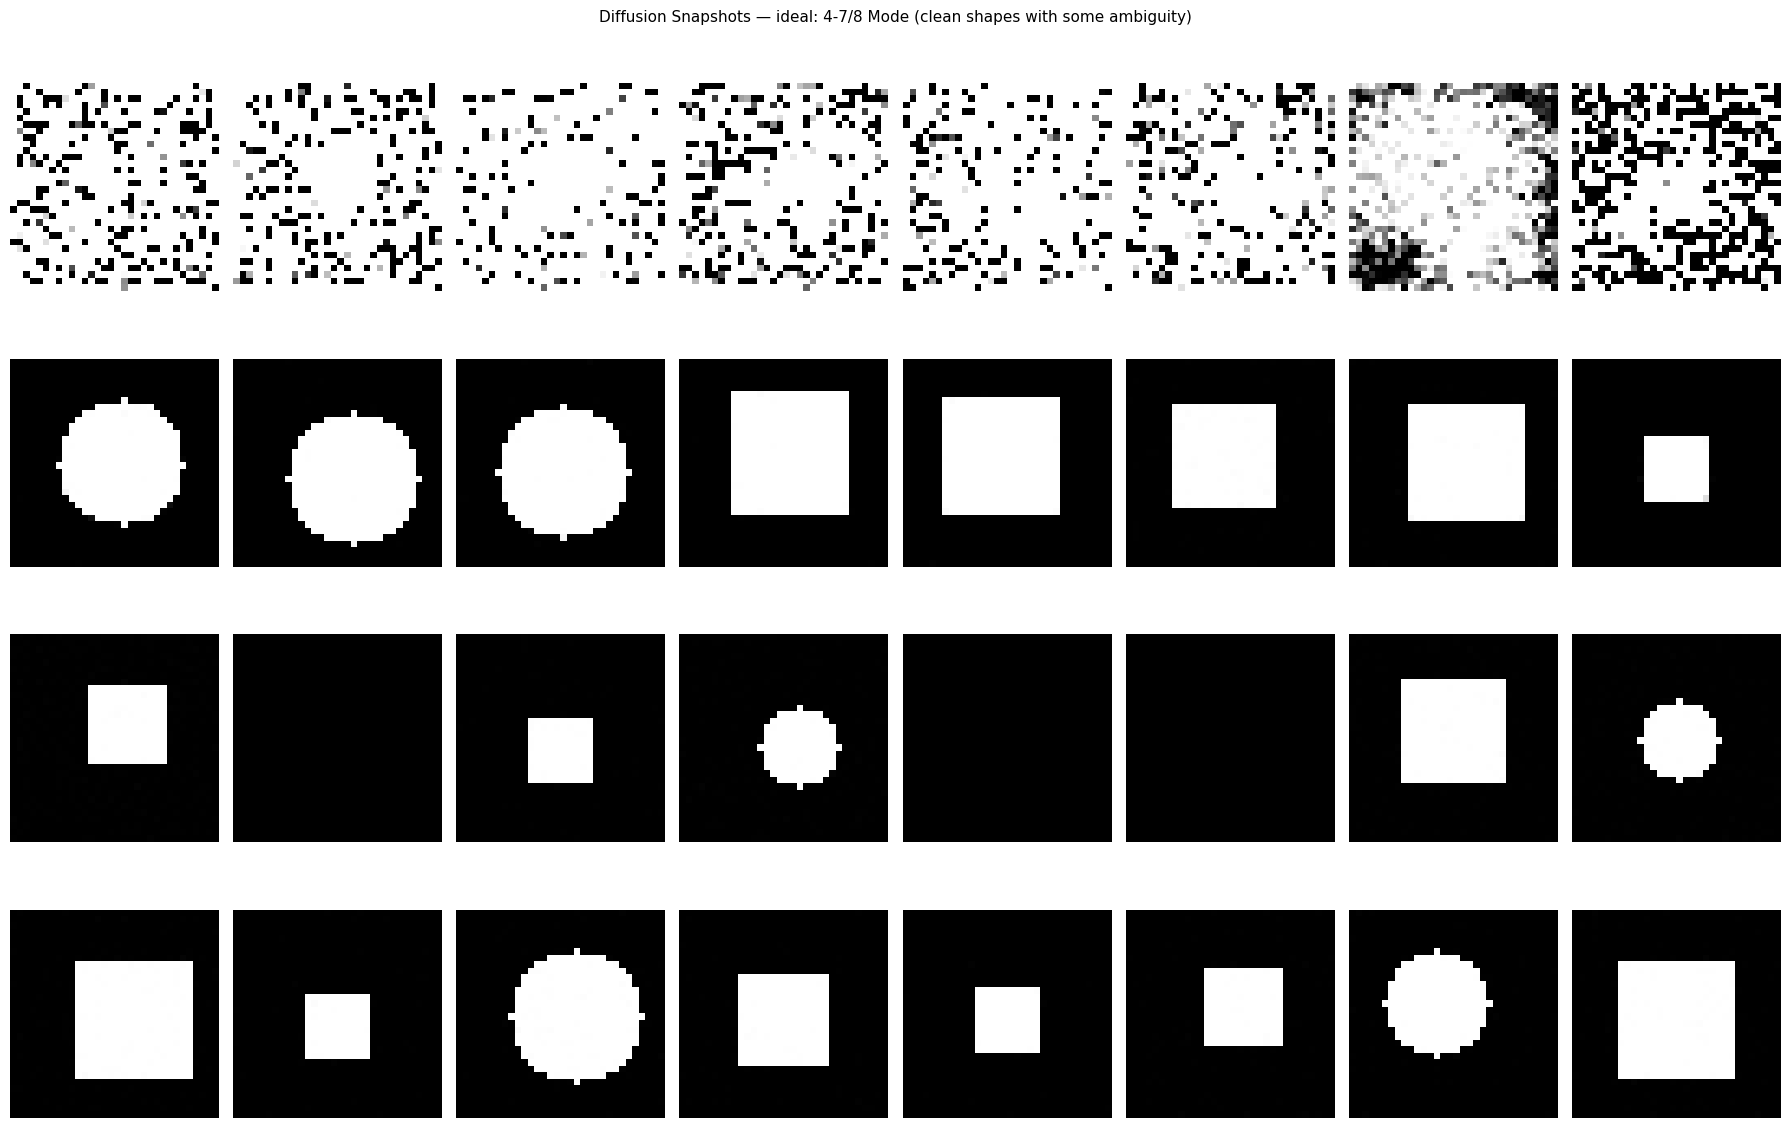


Quality gate — final snapshot classifications:
  Sample 1: Mode_Square
  Sample 2: Mode_Square
  Sample 3: Mode_Circle
  Sample 4: Mode_Square
  Sample 5: Mode_Square
  Sample 6: Mode_Square
  Sample 7: Mode_Circle
  Sample 8: Mode_Square

Mode: 8/8    Dead zone: 0/8

⚠️  WARNING: 8/8 Mode — model may be overtrained.
   At full generation this likely gives <1% dead zone samples.
   Recommended: reduce DIFF_EPOCHS by 1000 and retrain.
   Proceeding — check dead zone count in Section 11.


In [ ]:
n_snaps = len(snapshots)
fig, axes = plt.subplots(n_snaps, 8, figsize=(18, 3 * n_snaps))
if n_snaps == 1: axes = axes[None, :]

for row, (ep, imgs) in enumerate(sorted(snapshots.items())):
    for col in range(8):
        axes[row, col].imshow(imgs[col, 0], cmap='gray', vmin=-1, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'Epoch\n{ep}', rotation=0, labelpad=45, va='center', fontsize=9)

plt.suptitle('Diffusion Snapshots — ideal: 4-7/8 Mode (clean shapes with some ambiguity)',
             fontsize=11)
plt.tight_layout()
plt.savefig('diffusion_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()

final_snap   = snapshots[max(snapshots.keys())]
snap_labels  = [classify_image(final_snap[i, 0])[0] for i in range(8)]
mode_in_snap = sum(1 for l in snap_labels if 'Mode' in l)
dead_in_snap = sum(1 for l in snap_labels if 'Dead' in l)

print('\nQuality gate — final snapshot classifications:')
for i, l in enumerate(snap_labels):
    print(f'  Sample {i+1}: {l}')
print(f'\nMode: {mode_in_snap}/8    Dead zone: {dead_in_snap}/8')

if mode_in_snap <= 1:
    raise RuntimeError(
        f'❌ QUALITY GATE FAILED: only {mode_in_snap}/8 Mode.\n'
        f'   Model undertrained — images still blurry.\n'
        f'   Fix: increase DIFF_EPOCHS by 1000.')
elif mode_in_snap == 8:
    print('\n⚠️  WARNING: 8/8 Mode — model may be overtrained.')
    print('   At full generation this likely gives <1% dead zone samples.')
    print('   Recommended: reduce DIFF_EPOCHS by 1000 and retrain.')
    print('   Proceeding — check dead zone count in Section 11.')
else:
    print(f'\n✅ Quality gate passed: {mode_in_snap}/8 Mode, {dead_in_snap}/8 Dead zone')
    print('   Model is in the ideal regime.')

In [ ]:
print(f'\nGenerating {N_SAMPLES} samples with trajectory tracking...')
print(f'Collecting x₀ estimates at t=0..{VARIANCE_WINDOW-1} (ᾱ=[{window_start_alpha:.3f}→{window_end_alpha:.3f}])')
unet.eval()

xt               = torch.randn(N_SAMPLES, 1, IMG_SIZE, IMG_SIZE).to(device)
trajectory_stack = []

with torch.no_grad():
    for i in tqdm(reversed(range(N_STEPS)), desc='Sampling', total=N_STEPS):
        tb         = torch.full((N_SAMPLES,), i, dtype=torch.long).to(device)
        noise_pred = unet(xt, tb)
        ab         = alphas_cumprod[tb].view(-1, 1, 1, 1)
        x0_pred    = (xt - torch.sqrt(1 - ab) * noise_pred) / torch.sqrt(ab)
        x0_pred    = x0_pred.clamp(-1, 1)

        if i < VARIANCE_WINDOW:       
            trajectory_stack.append(x0_pred.cpu().float().numpy())

        if i > 0:
            b  = betas[tb].view(-1, 1, 1, 1)
            al = alphas[tb].view(-1, 1, 1, 1)
            xt = ((xt - (b / torch.sqrt(1 - ab)) * noise_pred) / torch.sqrt(al)
                  + torch.sqrt(b) * torch.randn_like(xt))
        else:
            xt = x0_pred

final_samples = xt.cpu().float().numpy()                    # (N, 1, H, W)
traj          = np.array(trajectory_stack)                  # (W, N, 1, H, W)
traj          = traj.transpose(1, 0, 2, 3, 4)[:, :, 0]     # (N, W, H, W)

print(f'Final samples:  {final_samples.shape}')
print(f'Trajectories:   {traj.shape}')


Generating 2000 samples with trajectory tracking...


Sampling: 100%|██████████| 100/100 [00:25<00:00,  3.97it/s]

Final samples:  (2000, 1, 32, 32)
Trajectories:   (2000, 50, 32, 32)


In [ ]:
var_per_px = np.var(traj.astype(np.float32), axis=1)   # (N, H, W)
variances  = var_per_px.mean(axis=(1, 2))               # (N,)

print(f'\nTrajectory Variance Statistics:')
print(f'  Min:    {variances.min():.8f}')
print(f'  Max:    {variances.max():.8f}')
print(f'  Mean:   {variances.mean():.8f}')
print(f'  Median: {np.median(variances):.8f}')
print(f'  Std:    {variances.std():.8f}')

if variances.max() < 1e-6:
    print('\n⚠️  All variances near zero — window is in wrong regime.')
    print('   This means ᾱ at window start is too high (>0.95).')
    print('   Fix: reduce N_STEPS. Current T=100 should fix this.')


Trajectory Variance Statistics:
  Min:    0.00000770
  Max:    0.06941500
  Mean:   0.00048816
  Median: 0.00002813
  Std:    0.00279431


In [13]:
# =============================================================================
# SECTION 11: CLASSIFY SAMPLES + KILL-SWITCH
# =============================================================================

print(f'\nClassifying {N_SAMPLES} generated samples...')
clf.eval()

regions, confidences, pred_classes = [], [], []
for start in range(0, N_SAMPLES, 200):
    end   = min(start + 200, N_SAMPLES)
    batch = torch.tensor(final_samples[start:end], dtype=torch.float32).to(device)
    with torch.no_grad():
        probs = F.softmax(clf(batch), dim=1)
    max_probs = probs.max(dim=1).values.cpu().numpy()
    preds_    = probs.argmax(dim=1).cpu().numpy()
    for p, pred in zip(max_probs, preds_):
        confidences.append(p)
        pred_classes.append(pred)
        is_dead = (pred == 2) or (p < DEAD_ZONE_CONF_THRESH)
        if is_dead:
            regions.append('DeadZone')
        elif p >= MODE_CONF_THRESH:
            regions.append('Mode_Circle' if pred == 0 else 'Mode_Square')
        else:
            regions.append('Transition')

confidences  = np.array(confidences)
pred_classes_arr = np.array(pred_classes)

mode_idx  = [i for i, r in enumerate(regions) if 'Mode' in r]
dead_idx  = [i for i, r in enumerate(regions) if r == 'DeadZone']
trans_idx = [i for i, r in enumerate(regions) if r == 'Transition']
mc_idx    = [i for i, r in enumerate(regions) if r == 'Mode_Circle']
ms_idx    = [i for i, r in enumerate(regions) if r == 'Mode_Square']

print(f'\nSample Distribution:')
print(f'  Mode (Circle):  {len(mc_idx):5d}  ({100*len(mc_idx)/N_SAMPLES:.1f}%)')
print(f'  Mode (Square):  {len(ms_idx):5d}  ({100*len(ms_idx)/N_SAMPLES:.1f}%)')
print(f'  Dead Zone:      {len(dead_idx):5d}  ({100*len(dead_idx)/N_SAMPLES:.1f}%)')
print(f'  Transition:     {len(trans_idx):5d}  ({100*len(trans_idx)/N_SAMPLES:.1f}%)')

mode_vars = variances[mode_idx] if mode_idx else np.array([1e-10])
dead_vars = variances[dead_idx] if dead_idx else np.array([0.0])
mean_mode = np.mean(mode_vars)
mean_dead = np.mean(dead_vars)
ratio     = mean_dead / mean_mode if (mean_mode > 0 and len(dead_idx) > 0) else 0.0
passed    = ratio > KILL_SWITCH_RATIO

print()
print('=' * 60)
print('PHASE 1 — STEP 1.2c :  SIMPLE SHAPES KILL-SWITCH')
print('=' * 60)
print(f'  Mode samples:               {len(mode_idx)}')
print(f'  Dead zone samples:          {len(dead_idx)}')
print(f'  Mean variance  (Mode):      {mean_mode:.8f}')
print(f'  Mean variance  (DeadZone):  {mean_dead:.8f}')
print(f'  RATIO:                      {ratio:.2f}')
print(f'  THRESHOLD:                  {KILL_SWITCH_RATIO}')
print(f'  RESULT: {"✅ PASS" if passed else "❌ FAIL"}')
print('=' * 60)

if len(dead_idx) < 10:
    print('\n⚠️  Fewer than 10 dead zone samples — ratio estimate unreliable.')
    print('   Fix: reduce DIFF_EPOCHS by 1000 and retrain diffusion model.')
elif len(dead_idx) > N_SAMPLES * 0.5:
    print('\n⚠️  >50% dead zone — model undertrained, blurry outputs.')
    print('   Fix: increase DIFF_EPOCHS by 1000 and retrain.')
elif not passed:
    print('\n⚠️  FAIL — variance does not separate zones.')
    print('   Check: is window_start_alpha < 0.90?  (see Section 2 output)')
    print('   Check: are dead zone samples genuinely ambiguous? (see Section 12 visuals)')


Classifying 2000 generated samples...

Sample Distribution:
  Mode (Circle):    954  (47.7%)
  Mode (Square):   1026  (51.3%)
  Dead Zone:         11  (0.6%)
  Transition:         9  (0.5%)

PHASE 1 — STEP 1.2c :  SIMPLE SHAPES KILL-SWITCH
  Mode samples:               1980
  Dead zone samples:          11
  Mean variance  (Mode):      0.00043674
  Mean variance  (DeadZone):  0.00761221
  RATIO:                      17.43
  THRESHOLD:                  5.0
  RESULT: ✅ PASS


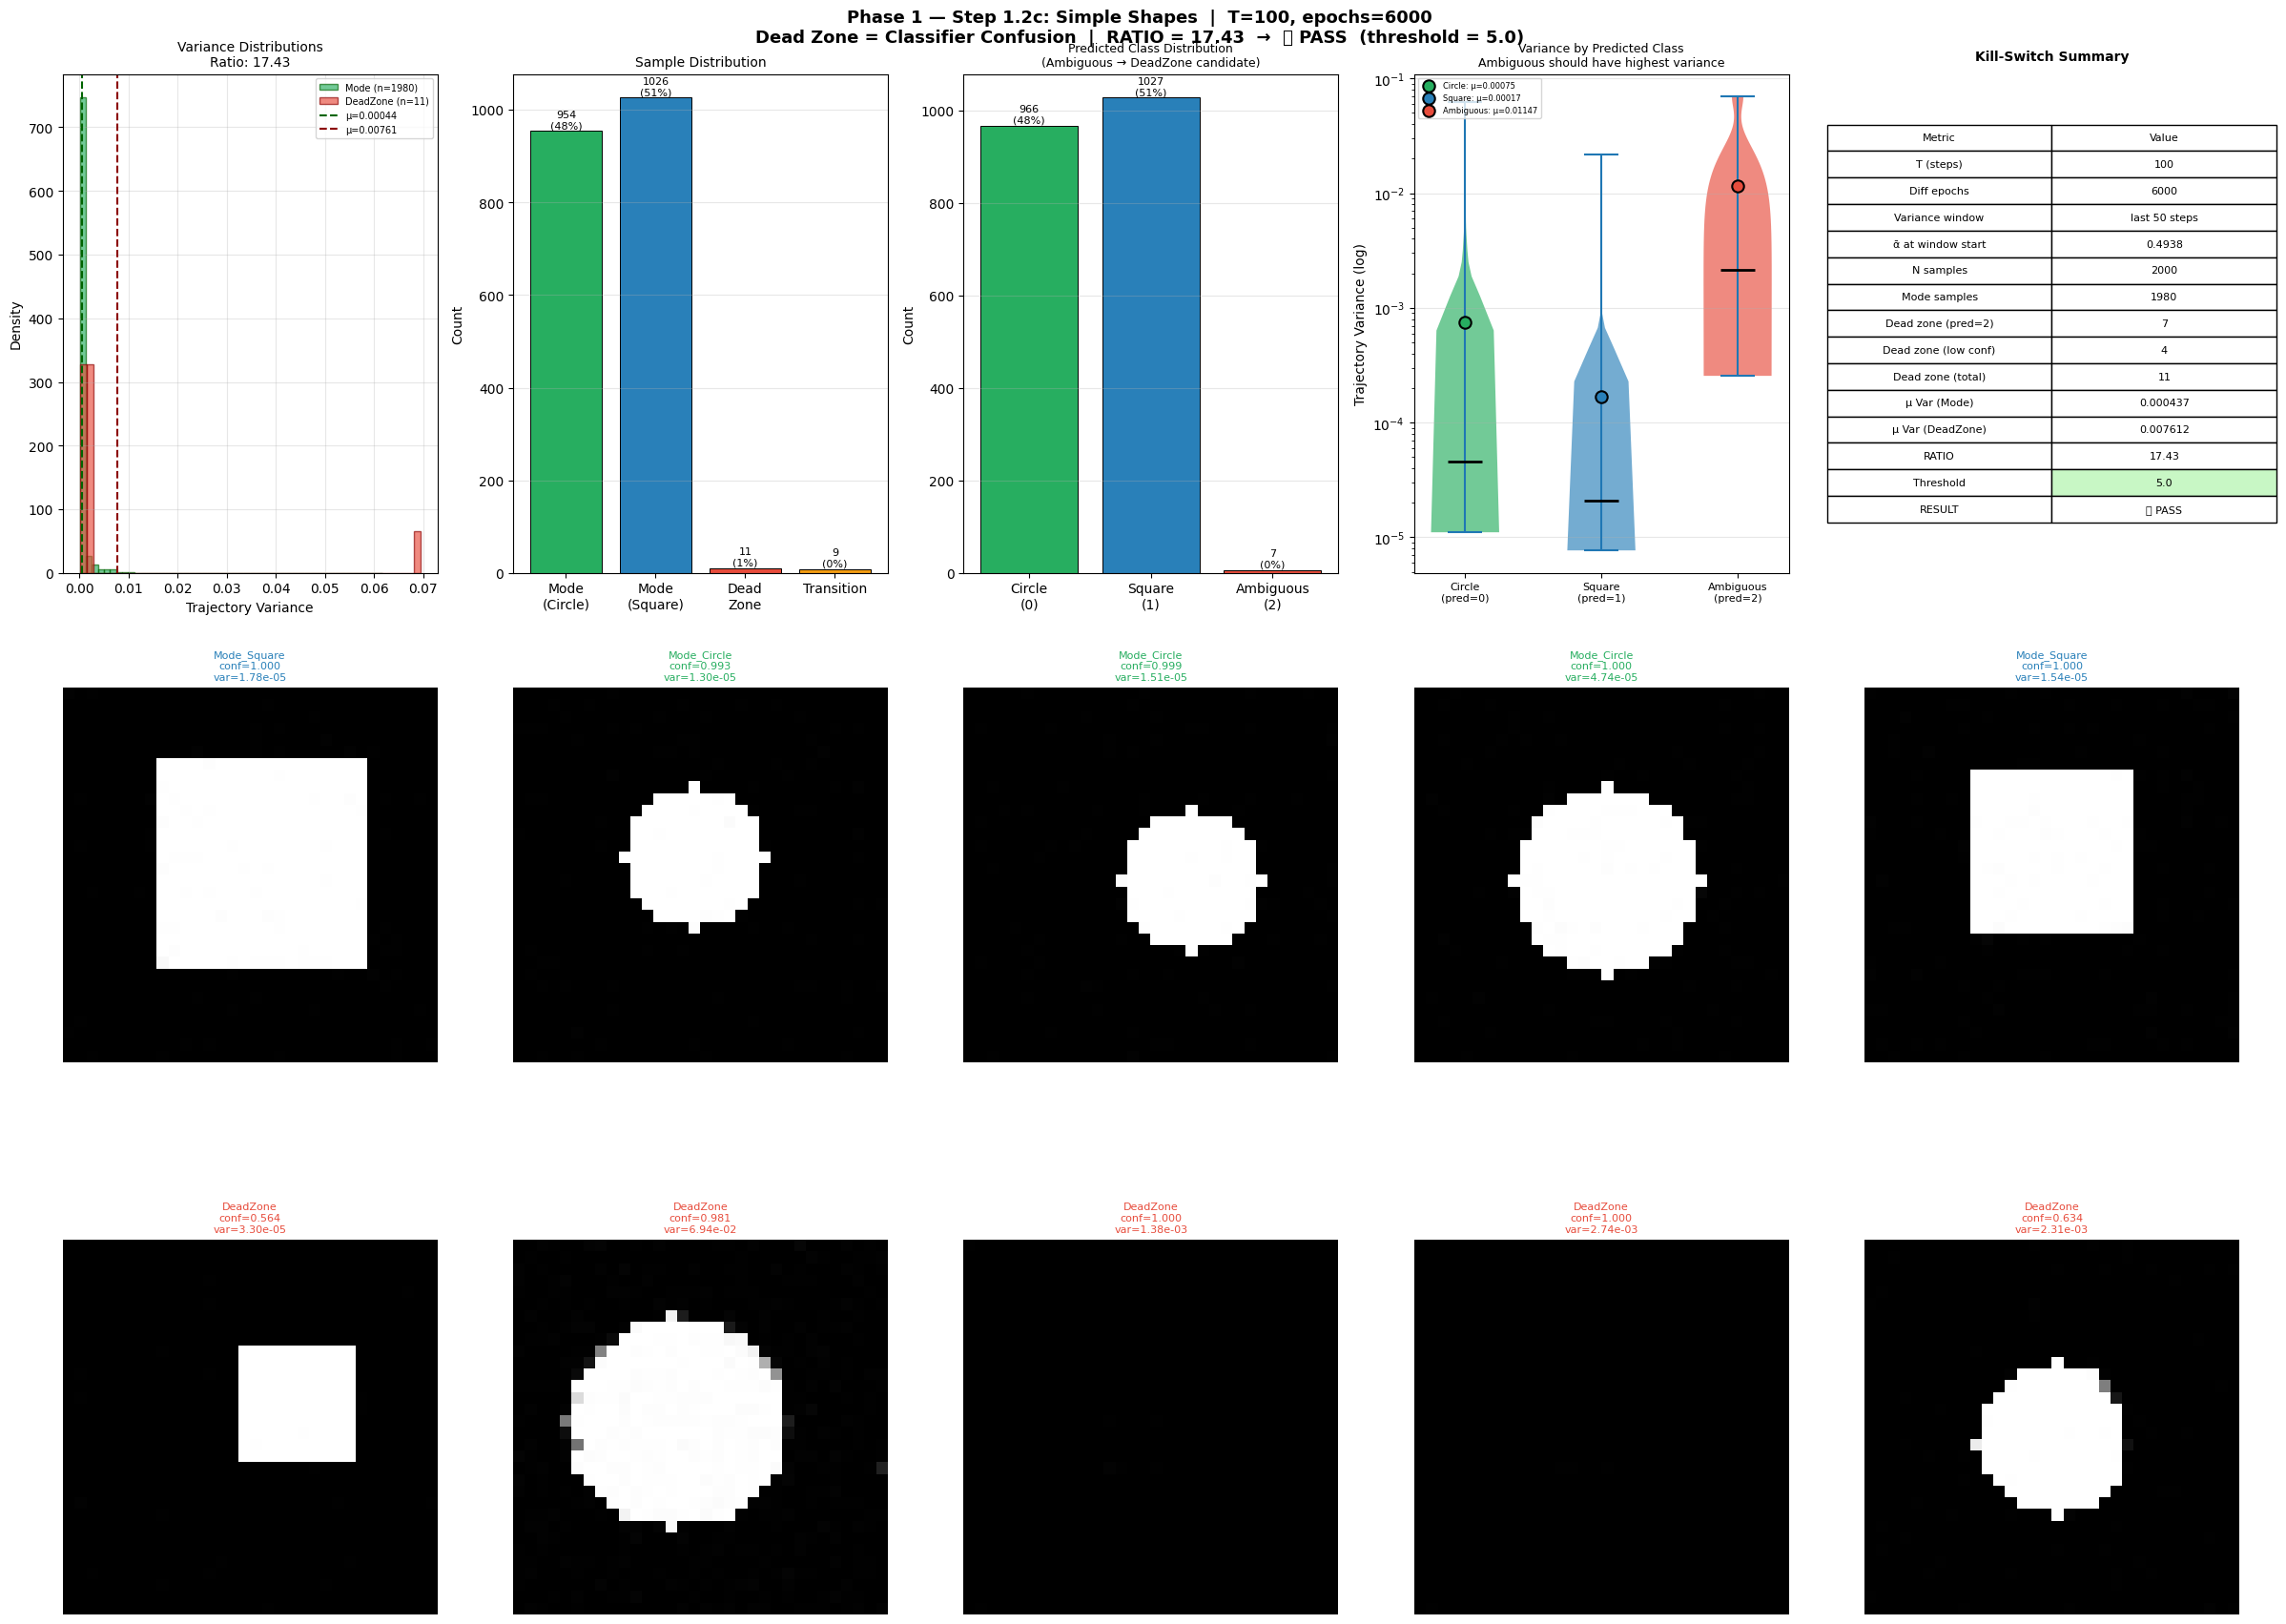

Saved: phase1_shapes_final.png


In [ ]:
fig = plt.figure(figsize=(24, 18))
fig.suptitle(
    f'Phase 1 — Step 1.2c: Simple Shapes  |  T={N_STEPS}, epochs={DIFF_EPOCHS}\n'
    f'Dead Zone = Classifier Confusion  |  '
    f'RATIO = {ratio:.2f}  →  {"✅ PASS" if passed else "❌ FAIL"}  '
    f'(threshold = {KILL_SWITCH_RATIO})',
    fontsize=13, fontweight='bold'
)
CLASS_COLORS = ['#27ae60', '#2980b9', '#e74c3c']

ax = fig.add_subplot(3, 5, 1)
if len(mode_idx) > 1:
    ax.hist(mode_vars, bins=50, alpha=0.65, density=True,
            color='#27ae60', edgecolor='darkgreen', label=f'Mode (n={len(mode_idx)})')
if len(dead_idx) > 1:
    ax.hist(dead_vars, bins=50, alpha=0.65, density=True,
            color='#e74c3c', edgecolor='darkred', label=f'DeadZone (n={len(dead_idx)})')
ax.axvline(mean_mode, color='darkgreen', ls='--', lw=1.5, label=f'μ={mean_mode:.5f}')
ax.axvline(mean_dead, color='darkred',   ls='--', lw=1.5, label=f'μ={mean_dead:.5f}')
ax.set_title(f'Variance Distributions\nRatio: {ratio:.2f}', fontsize=10)
ax.set_xlabel('Trajectory Variance'); ax.set_ylabel('Density')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

ax = fig.add_subplot(3, 5, 2)
counts = [len(mc_idx), len(ms_idx), len(dead_idx), len(trans_idx)]
labels = ['Mode\n(Circle)', 'Mode\n(Square)', 'Dead\nZone', 'Transition']
colors = ['#27ae60', '#2980b9', '#e74c3c', '#f39c12']
bars   = ax.bar(labels, counts, color=colors, edgecolor='black', lw=0.7)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{cnt}\n({100*cnt/N_SAMPLES:.0f}%)', ha='center', va='bottom', fontsize=8)
ax.set_title('Sample Distribution', fontsize=10)
ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)

ax = fig.add_subplot(3, 5, 3)
class_counts = [(pred_classes_arr == c).sum() for c in range(3)]
bars = ax.bar(['Circle\n(0)', 'Square\n(1)', 'Ambiguous\n(2)'],
              class_counts, color=CLASS_COLORS, edgecolor='black', lw=0.7)
for bar, cnt in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{cnt}\n({100*cnt/N_SAMPLES:.0f}%)', ha='center', va='bottom', fontsize=8)
ax.set_title('Predicted Class Distribution\n(Ambiguous → DeadZone candidate)', fontsize=9)
ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)

ax = fig.add_subplot(3, 5, 4)
class_var_data = [variances[pred_classes_arr == c] for c in range(3)]
valid          = [(i, d) for i, d in enumerate(class_var_data) if len(d) > 1]
if valid:
    parts = ax.violinplot([d for _, d in valid],
                          positions=[i for i, _ in valid],
                          showmedians=True, showmeans=False)
    for pc, (i, _) in zip(parts['bodies'], valid):
        pc.set_facecolor(CLASS_COLORS[i]); pc.set_alpha(0.65)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
for i, d in enumerate(class_var_data):
    if len(d) > 0:
        ax.scatter(i, np.mean(d), color=CLASS_COLORS[i], s=80,
                   zorder=5, edgecolors='black', lw=1.5,
                   label=f'{CLASS_NAMES[i]}: μ={np.mean(d):.5f}')
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Circle\n(pred=0)', 'Square\n(pred=1)', 'Ambiguous\n(pred=2)'], fontsize=8)
if variances.max() > 1e-8:
    ax.set_yscale('log')
ax.set_ylabel('Trajectory Variance (log)')
ax.set_title('Variance by Predicted Class\nAmbiguous should have highest variance', fontsize=9)
ax.legend(fontsize=6, loc='upper left'); ax.grid(alpha=0.3, axis='y')

ax = fig.add_subplot(3, 5, 5)
ax.axis('off')
n_ambig   = (pred_classes_arr == 2).sum()
n_lowconf = sum(1 for p, pr in zip(confidences, pred_classes)
                if pr != 2 and p < DEAD_ZONE_CONF_THRESH)
table_data = [
    ['T (steps)',            str(N_STEPS)],
    ['Diff epochs',          str(DIFF_EPOCHS)],
    ['Variance window',      f'last {VARIANCE_WINDOW} steps'],
    ['ᾱ at window start',   f'{window_start_alpha:.4f}'],
    ['N samples',            str(N_SAMPLES)],
    ['Mode samples',         str(len(mode_idx))],
    ['Dead zone (pred=2)',   str(n_ambig)],
    ['Dead zone (low conf)', str(n_lowconf)],
    ['Dead zone (total)',    str(len(dead_idx))],
    ['μ Var (Mode)',         f'{mean_mode:.6f}'],
    ['μ Var (DeadZone)',     f'{mean_dead:.6f}'],
    ['RATIO',                f'{ratio:.2f}'],
    ['Threshold',            str(KILL_SWITCH_RATIO)],
    ['RESULT',               '✅ PASS' if passed else '❌ FAIL'],
]
tbl = ax.table(cellText=table_data, colLabels=['Metric', 'Value'],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
tbl.scale(1.2, 1.3)
tbl[13, 1].set_facecolor('#c8f7c5' if passed else '#fcc')
ax.set_title('Kill-Switch Summary', fontsize=10, fontweight='bold', pad=10)

show_mode = (mode_idx[:5] if len(mode_idx) >= 5 else mode_idx + [None]*5)[:5]
for col, idx in enumerate(show_mode):
    ax = fig.add_subplot(3, 5, 6 + col)
    if idx is not None:
        ax.imshow(final_samples[idx, 0], cmap='gray', vmin=-1, vmax=1)
        ax.set_title(f'{regions[idx]}\nconf={confidences[idx]:.3f}\nvar={variances[idx]:.2e}',
                     fontsize=8, color=CMAP[regions[idx]])
    else:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
    ax.axis('off')
    if col == 0:
        ax.set_ylabel('Mode\nsamples', rotation=0, labelpad=45, va='center',
                      fontsize=9, color='#27ae60', fontweight='bold')

show_dead = (dead_idx[:5] if len(dead_idx) >= 5 else dead_idx + [None]*5)[:5]
for col, idx in enumerate(show_dead):
    ax = fig.add_subplot(3, 5, 11 + col)
    if idx is not None:
        ax.imshow(final_samples[idx, 0], cmap='gray', vmin=-1, vmax=1)
        ax.set_title(f'DeadZone\nconf={confidences[idx]:.3f}\nvar={variances[idx]:.2e}',
                     fontsize=8, color='#e74c3c')
    else:
        ax.text(0.5, 0.5, 'N/A\n(no dead\nzone samples)',
                ha='center', va='center', transform=ax.transAxes, fontsize=9, color='gray')
    ax.axis('off')
    if col == 0:
        ax.set_ylabel('Dead Zone\nsamples', rotation=0, labelpad=45, va='center',
                      fontsize=9, color='#e74c3c', fontweight='bold')

plt.tight_layout()
plt.savefig('phase1_shapes_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase1_shapes_final.png')

In [ ]:
print()
print('=' * 68)
print('PHASE 1 — STEP 1.2c  COMPLETE SUMMARY')
print('=' * 68)
print(f'  Dataset:              Simple Shapes (Circle / Square, {IMG_SIZE}×{IMG_SIZE})')
print(f'  Noise schedule:       Cosine  (ᾱ_T = {alphas_cumprod[-1].item():.5f})')
print(f'  Diffusion steps T:    {N_STEPS}')
print(f'  Diff training epochs: {DIFF_EPOCHS}')
print(f'  Variance window:      last {VARIANCE_WINDOW} steps (t=0..{VARIANCE_WINDOW-1})')
print(f'    ᾱ at window start:  {window_start_alpha:.4f}  ({window_start_alpha*100:.0f}% signal)')
print(f'    ᾱ at window end:    {window_end_alpha:.5f}')
print()
print(f'  Dead Zone Definition (two-pronged):')
print(f'    (a) Classifier predicts Ambiguous (class 2): {n_ambig} samples')
print(f'    (b) Classifier uncertain (conf < {DEAD_ZONE_CONF_THRESH}):       {n_lowconf} samples')
print(f'    Total dead zone: {len(dead_idx)} / {N_SAMPLES}  ({100*len(dead_idx)/N_SAMPLES:.1f}%)')
print(f'  (analogous to CLIP score < threshold in Phase 4)')
print()
print(f'  Mode samples:         {len(mode_idx)} / {N_SAMPLES}  ({100*len(mode_idx)/N_SAMPLES:.1f}%)')
print(f'  Transition:           {len(trans_idx)} / {N_SAMPLES}  ({100*len(trans_idx)/N_SAMPLES:.1f}%)')
print()
print(f'  Mean Var (Mode):      {mean_mode:.8f}')
print(f'  Mean Var (DeadZone):  {mean_dead:.8f}')
print(f'  RATIO:                {ratio:.2f}')
print(f'  THRESHOLD:            {KILL_SWITCH_RATIO}')
print()
print(f'  RESULT: {"✅ PASS — variance detects mode interpolation in image space" if passed else "❌ FAIL"}')
print('=' * 68)
print()
print('Parallel to main T2I study:')
print('  3-class classifier uncertainty (shapes) ↔ CLIP score (Stable Diffusion)')
print('  pred==Ambiguous OR low conf here        ↔ CLIP < threshold in Phase 4')
print(f'  Variance window t=0..{VARIANCE_WINDOW-1} / T={N_STEPS}       ↔ Variance window last steps in Phase 3')
print()
print('If RESULT = FAIL, check in order:')
print('  1. Dead zone count < 10?  → reduce DIFF_EPOCHS by 1000')
print('  2. All variances ≈ 0?     → check Section 2: window_start_alpha should be < 0.90')
print('  3. Ratio ≈ 1?             → dead zone samples have same variance as mode → window wrong')



PHASE 1 — STEP 1.2c  COMPLETE SUMMARY
  Dataset:              Simple Shapes (Circle / Square, 32×32)
  Noise schedule:       Cosine  (ᾱ_T = 0.00000)
  Diffusion steps T:    100
  Diff training epochs: 6000
  Variance window:      last 50 steps (t=0..49)
    ᾱ at window start:  0.4938  (49% signal)
    ᾱ at window end:    0.99937

  Dead Zone Definition (two-pronged):
    (a) Classifier predicts Ambiguous (class 2): 7 samples
    (b) Classifier uncertain (conf < 0.6):       4 samples
    Total dead zone: 11 / 2000  (0.6%)
  (analogous to CLIP score < threshold in Phase 4)

  Mode samples:         1980 / 2000  (99.0%)
  Transition:           9 / 2000  (0.5%)

  Mean Var (Mode):      0.00043674
  Mean Var (DeadZone):  0.00761221
  RATIO:                17.43
  THRESHOLD:            5.0

  RESULT: ✅ PASS — variance detects mode interpolation in image space

Parallel to main T2I study:
  3-class classifier uncertainty (shapes) ↔ CLIP score (Stable Diffusion)
  pred==Ambiguous OR low conf h